# Rate Limiter Traffic Analysis

Batch analysis of request events stored in TimescaleDB.
Answers five key questions about traffic patterns and rate limiting behaviour.

In [1]:
import os
import pandas as pd
import sqlalchemy
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

engine = sqlalchemy.create_engine(os.environ['TIMESCALE_URL'])

raw = pd.read_sql("SELECT * FROM request_events ORDER BY time", engine)
rollups = pd.read_sql("SELECT * FROM request_metrics_1m ORDER BY bucket", engine)

raw['time'] = pd.to_datetime(raw['time'], utc=True)
rollups['bucket'] = pd.to_datetime(rollups['bucket'], utc=True)

print(f"Loaded {len(raw):,} raw events and {len(rollups):,} rollup rows")
print(f"Time range: {raw['time'].min()} → {raw['time'].max()}")
print(f"Unique clients: {raw['client_id'].nunique()}")
print(f"Status breakdown:\n{raw['status'].value_counts().to_string()}")

Loaded 356,494 raw events and 2,442 rollup rows
Time range: 2026-03-25 02:22:16.222463+00:00 → 2026-03-28 00:04:04.151018+00:00
Unique clients: 56
Status breakdown:
status
rejected        159570
allowed         129733
circuit_open     67191


## 1. Which hour of the day has the highest rejection rate?

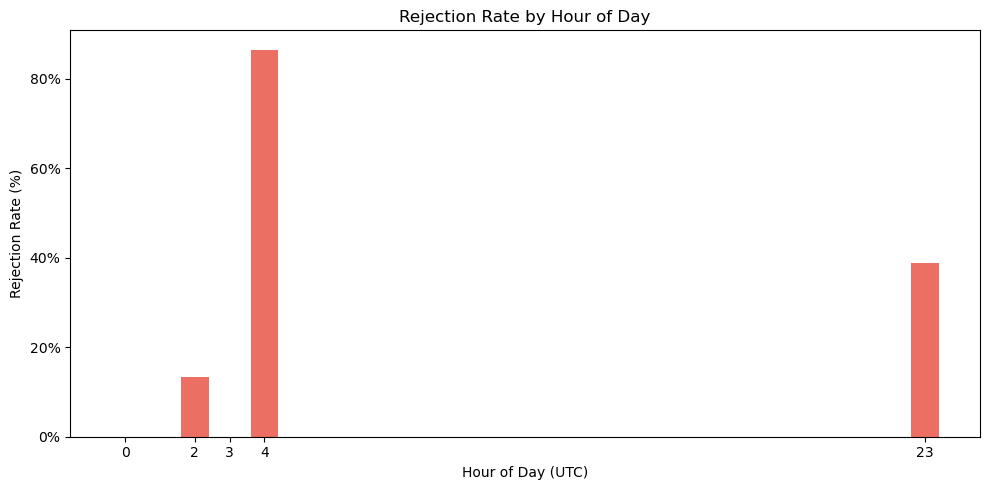


Peak rejection hour: 4:00 UTC (86.5%)
Total rejected in that hour: 92,751 / 107,285


In [2]:
hourly = raw.groupby(raw['time'].dt.hour).agg(
    total=('status', 'count'),
    rejected=('status', lambda x: (x == 'rejected').sum())
)
hourly['rejection_rate'] = hourly['rejected'] / hourly['total'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly.index, hourly['rejection_rate'], color='#e74c3c', alpha=0.8)
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Rejection Rate (%)')
ax.set_title('Rejection Rate by Hour of Day')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(hourly.index)
plt.tight_layout()
plt.show()

peak_hour = hourly['rejection_rate'].idxmax()
print(f"\nPeak rejection hour: {peak_hour}:00 UTC ({hourly.loc[peak_hour, 'rejection_rate']:.1f}%)")
print(f"Total rejected in that hour: {hourly.loc[peak_hour, 'rejected']:,} / {hourly.loc[peak_hour, 'total']:,}")

## 2. Are there clients with automated request patterns? (low inter-arrival variance)

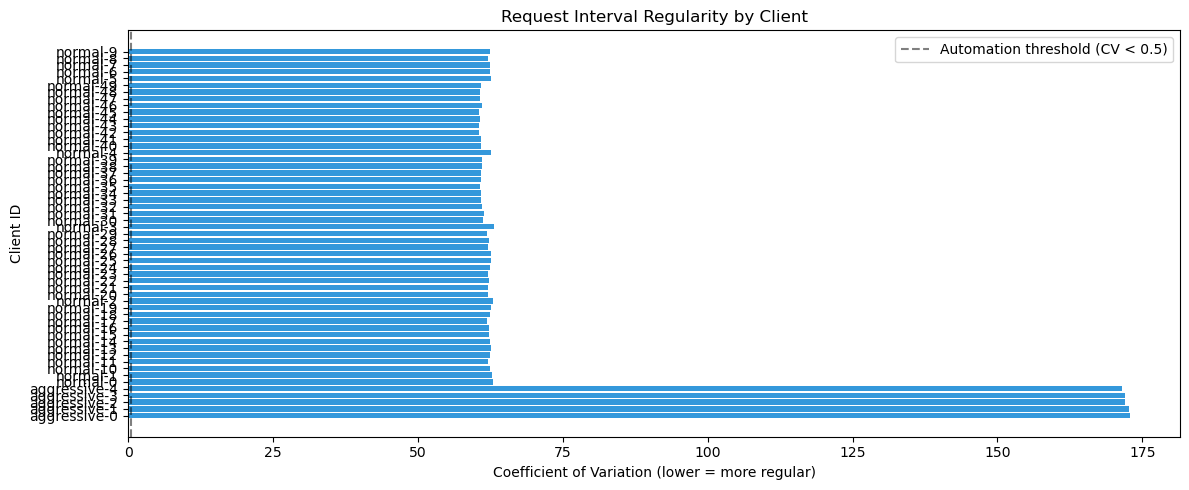


Clients with automated-looking patterns (CV < 0.5): 0
No clients show highly regular (automated) request intervals.


In [3]:
client_events = raw.sort_values(['client_id', 'time'])
client_events['interval'] = client_events.groupby('client_id')['time'].diff().dt.total_seconds()

interval_stats = client_events.groupby('client_id')['interval'].agg(['mean', 'std', 'count']).dropna()
interval_stats = interval_stats[interval_stats['count'] >= 10]
interval_stats['cv'] = interval_stats['std'] / interval_stats['mean']

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if cv < 0.5 else '#3498db' for cv in interval_stats['cv']]
ax.barh(interval_stats.index, interval_stats['cv'], color=colors)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Automation threshold (CV < 0.5)')
ax.set_xlabel('Coefficient of Variation (lower = more regular)')
ax.set_ylabel('Client ID')
ax.set_title('Request Interval Regularity by Client')
ax.legend()
plt.tight_layout()
plt.show()

automated = interval_stats[interval_stats['cv'] < 0.5]
print(f"\nClients with automated-looking patterns (CV < 0.5): {len(automated)}")
if len(automated) > 0:
    print(automated[['mean', 'std', 'cv']].round(3).to_string())
else:
    print("No clients show highly regular (automated) request intervals.")

## 3. Correlation between traffic volume and p99 latency

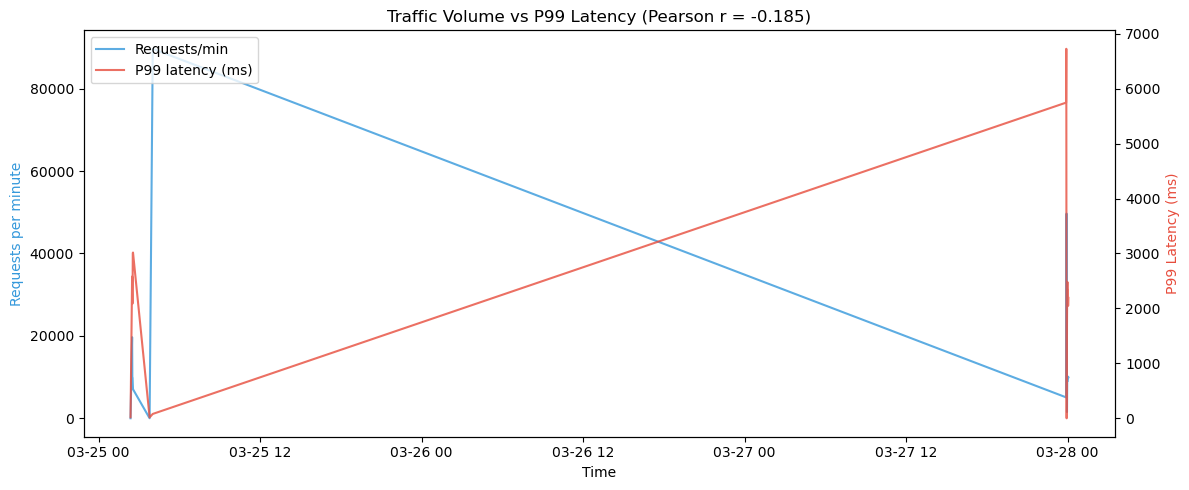


Pearson correlation: -0.185
Weak correlation — latency is relatively stable across traffic levels.


In [4]:
corr_data = rollups.groupby('bucket').agg(
    total_requests=('total_requests', 'sum'),
    p99_latency=('p99_latency_ms', 'max')
).dropna()

correlation = corr_data['total_requests'].corr(corr_data['p99_latency'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(corr_data.index, corr_data['total_requests'], color='#3498db', alpha=0.8, label='Requests/min')
ax2.plot(corr_data.index, corr_data['p99_latency'], color='#e74c3c', alpha=0.8, label='P99 latency (ms)')

ax1.set_xlabel('Time')
ax1.set_ylabel('Requests per minute', color='#3498db')
ax2.set_ylabel('P99 Latency (ms)', color='#e74c3c')
ax1.set_title(f'Traffic Volume vs P99 Latency (Pearson r = {correlation:.3f})')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"\nPearson correlation: {correlation:.3f}")
if abs(correlation) > 0.5:
    print("Strong correlation — higher traffic volume drives up tail latency.")
else:
    print("Weak correlation — latency is relatively stable across traffic levels.")

## 4. Most-hit endpoint by rejected clients

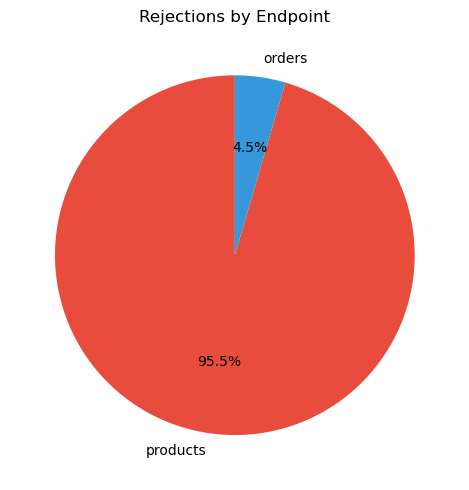


Most rejected endpoint: products (152,330 rejections)

Full breakdown:
  products: 152,330 (95.5%)
  orders: 7,240 (4.5%)


In [5]:
rejected = raw[raw['status'] == 'rejected']
endpoint_rejections = rejected.groupby('endpoint').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
endpoint_rejections.plot.pie(ax=ax, autopct='%1.1f%%', startangle=90, colors=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
ax.set_ylabel('')
ax.set_title('Rejections by Endpoint')
plt.tight_layout()
plt.show()

print(f"\nMost rejected endpoint: {endpoint_rejections.index[0]} ({endpoint_rejections.iloc[0]:,} rejections)")
print(f"\nFull breakdown:")
for ep, count in endpoint_rejections.items():
    print(f"  {ep}: {count:,} ({count/len(rejected)*100:.1f}%)")

## 5. Pareto: what % of rejections come from the top 3 clients?

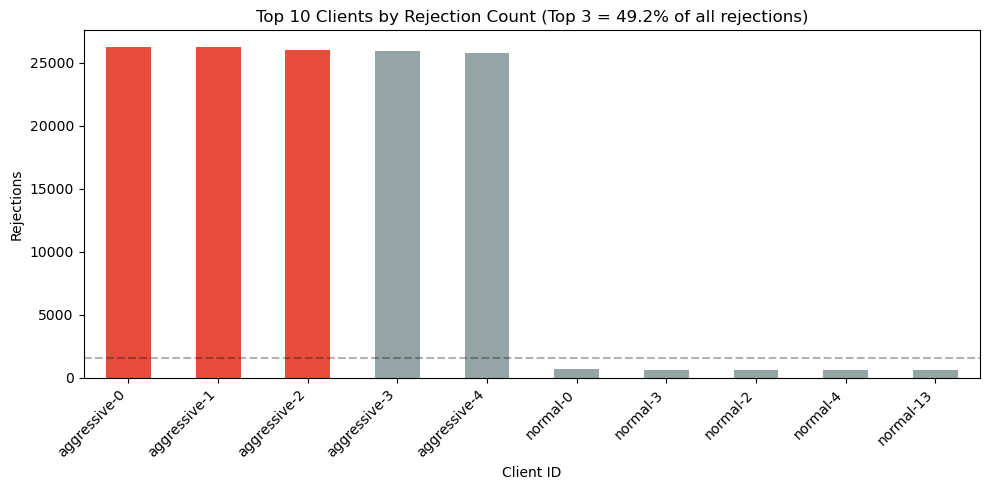


Total rejections: 159,570
Top 3 clients account for 49.2% of all rejections:
  aggressive-0: 26,264 (16.5%)
  aggressive-1: 26,231 (16.4%)
  aggressive-2: 26,007 (16.3%)

Pareto check: NO — top 3 clients account for < 60% of rejections


In [6]:
client_rejections = rejected.groupby('client_id').size().sort_values(ascending=False)
total_rejections = client_rejections.sum()
top3 = client_rejections.head(3)
top3_pct = top3.sum() / total_rejections * 100

fig, ax = plt.subplots(figsize=(10, 5))
top_n = client_rejections.head(10)
colors = ['#e74c3c' if i < 3 else '#95a5a6' for i in range(len(top_n))]
top_n.plot.bar(ax=ax, color=colors)
ax.set_xlabel('Client ID')
ax.set_ylabel('Rejections')
ax.set_title(f'Top 10 Clients by Rejection Count (Top 3 = {top3_pct:.1f}% of all rejections)')
ax.axhline(y=total_rejections * 0.01, color='black', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal rejections: {total_rejections:,}")
print(f"Top 3 clients account for {top3_pct:.1f}% of all rejections:")
for client, count in top3.items():
    print(f"  {client}: {count:,} ({count/total_rejections*100:.1f}%)")
print(f"\nPareto check: {'YES' if top3_pct >= 60 else 'NO'} — top 3 clients account for {'>' if top3_pct >= 60 else '<'} 60% of rejections")